In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn datasets

   ---------------------------------------- 0.0/527.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.5 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.5 kB ? eta -:--:--
   ---------------------------------------- 527.5/527.5 kB 1.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/616.3 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/616.3 kB ? eta -:--:--
   ---------------------------------------- 616.3/616.3 kB 3.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
    --------------------------------------- 0.5/27.5 MB 4.0 MB/s eta 0:00:07
   - -------------------------------------- 1.3/27.5 MB 3.5 MB/s eta 0:00:08
   -- ------------------------------------- 1.6/27.5 MB 3.1 MB/s eta 0:00:09
   --- ------------------------------------ 2.1/27.5 MB 2.7 MB/s eta 0:00:10
   --- ------------------------------------ 2.6/27.5 MB 2.5 MB/s eta 0:00:10
   ---- ------------------


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from datasets import load_dataset

from collections import Counter
import re
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# use subset for faster training
train_subset = torch.utils.data.Subset(train_dataset, range(10000))
test_subset = torch.utils.data.Subset(test_dataset, range(2000))

train_loader = torch.utils.data.DataLoader(train_subset,batch_size=64,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset,batch_size=64)

In [4]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN,self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.BatchNorm2d(64)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,10)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

cnn_model = SimpleCNN().to(device)

In [5]:
def train_model(model,epochs=3):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=0.001)

    losses = []
    start = time.time()

    for epoch in range(epochs):

        running_loss = 0

        for images,labels in train_loader:

            images,labels = images.to(device),labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        losses.append(running_loss)

        print("Epoch:",epoch+1,"Loss:",running_loss)

    print("Training Time:",time.time()-start)

    return losses

In [6]:
cnn_losses = train_model(cnn_model,epochs=3)

Epoch: 1 Loss: 91.58744876086712
Epoch: 2 Loss: 60.93660947680473
Epoch: 3 Loss: 50.30394046008587
Training Time: 92.92226839065552


In [7]:
correct = 0
total = 0

y_true = []
y_pred = []

cnn_model.eval()

with torch.no_grad():

    for images,labels in test_loader:

        images,labels = images.to(device),labels.to(device)

        outputs = cnn_model(images)

        _,predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted==labels).sum().item()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy = 100*correct/total
print("CNN Accuracy:",accuracy)

CNN Accuracy: 88.45


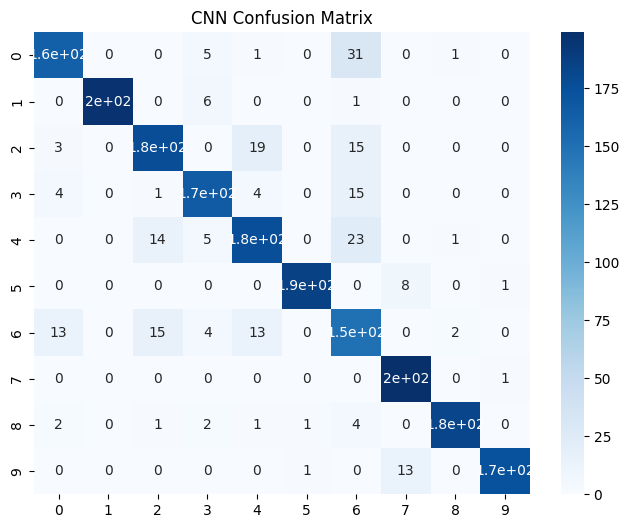

In [8]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.show()

In [9]:
from torchvision.models import resnet18

transfer_model = resnet18(pretrained=True)

transfer_model.conv1 = nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3,bias=False)

transfer_model.fc = nn.Linear(512,10)

transfer_model = transfer_model.to(device)

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
transfer_losses = train_model(transfer_model,epochs=2)

Epoch: 1 Loss: 113.87610247731209
Epoch: 2 Loss: 76.69581389427185
Training Time: 263.3891062736511


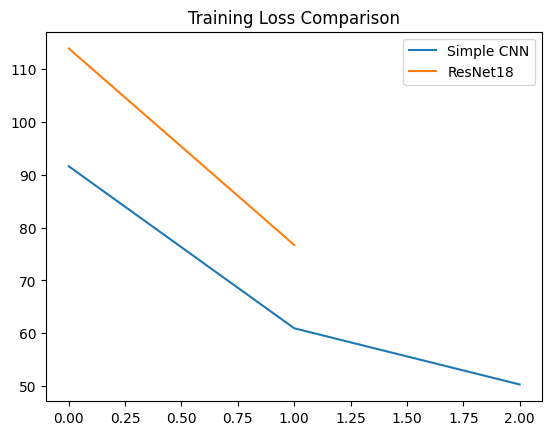

In [11]:
plt.plot(cnn_losses,label="Simple CNN")
plt.plot(transfer_losses,label="ResNet18")
plt.legend()
plt.title("Training Loss Comparison")
plt.show()

In [12]:
dataset = load_dataset("imdb")

train_data = dataset["train"].select(range(5000))
test_data = dataset["test"].select(range(2000))

README.md: 0.00B [00:00, ?B/s]

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [13]:
def tokenize(text):

    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]','',text)

    return text.split()

In [14]:
counter = Counter()

for sample in train_data:
    counter.update(tokenize(sample["text"]))

vocab = {word:i+2 for i,(word,_) in enumerate(counter.most_common(10000))}

vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

vocab_size = len(vocab)
print("Vocab size:",vocab_size)

Vocab size: 10002


In [15]:
max_len = 200

def encode(text):

    tokens = tokenize(text)

    ids = [vocab.get(word,1) for word in tokens]

    if len(ids) < max_len:
        ids += [0]*(max_len-len(ids))
    else:
        ids = ids[:max_len]

    return torch.tensor(ids)

In [16]:
X_train = torch.stack([encode(x["text"]) for x in train_data])
y_train = torch.tensor([x["label"] for x in train_data])

X_test = torch.stack([encode(x["text"]) for x in test_data])
y_test = torch.tensor([x["label"] for x in test_data])

In [17]:
train_dataset = torch.utils.data.TensorDataset(X_train,y_train)
test_dataset = torch.utils.data.TensorDataset(X_test,y_test)

train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=64)

In [18]:
class RNNModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size,64)
        self.rnn = nn.RNN(64,128,batch_first=True)
        self.fc = nn.Linear(128,2)

    def forward(self,x):

        x = self.embedding(x)
        out,_ = self.rnn(x)

        out = out[:,-1,:]

        return self.fc(out)

In [19]:
class LSTMModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size,64)
        self.lstm = nn.LSTM(64,128,batch_first=True)
        self.fc = nn.Linear(128,2)

    def forward(self,x):

        x = self.embedding(x)

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)

In [20]:
class GRUModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size,64)
        self.gru = nn.GRU(64,128,batch_first=True)
        self.fc = nn.Linear(128,2)

    def forward(self,x):

        x = self.embedding(x)

        out,_ = self.gru(x)

        out = out[:,-1,:]

        return self.fc(out)

In [21]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(100,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,784),
            nn.Tanh()
        )

    def forward(self,z):

        img = self.model(z)

        return img.view(-1,1,28,28)

In [22]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,img):

        return self.model(img)

In [25]:
gan_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

gan_loader = torch.utils.data.DataLoader(
    gan_dataset,
    batch_size=64,
    shuffle=True
)

In [26]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(generator.parameters(), lr=0.0002)
opt_D = optim.Adam(discriminator.parameters(), lr=0.0002)

epochs = 5

for epoch in range(epochs):

    for imgs,_ in gan_loader:   # ⭐ use GAN loader

        imgs = imgs.to(device).float()

        batch = imgs.size(0)

        real = torch.ones(batch,1).to(device)
        fake = torch.zeros(batch,1).to(device)

        # --------------------
        # Train Discriminator
        # --------------------

        z = torch.randn(batch,100).to(device)
        gen_imgs = generator(z)

        real_loss = criterion(discriminator(imgs), real)
        fake_loss = criterion(discriminator(gen_imgs.detach()), fake)

        d_loss = real_loss + fake_loss

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # --------------------
        # Train Generator
        # --------------------

        g_loss = criterion(discriminator(gen_imgs), real)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 1/5 | D Loss: 0.7857 | G Loss: 3.7501
Epoch 2/5 | D Loss: 0.6066 | G Loss: 4.1080
Epoch 3/5 | D Loss: 0.1898 | G Loss: 3.1779
Epoch 4/5 | D Loss: 0.5083 | G Loss: 5.9888
Epoch 5/5 | D Loss: 0.3697 | G Loss: 3.1834


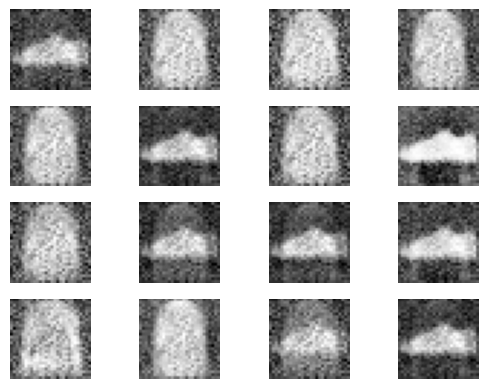

In [27]:
z = torch.randn(16,100).to(device)

samples = generator(z).cpu().detach()

fig,axs = plt.subplots(4,4)

k = 0
for i in range(4):
    for j in range(4):

        axs[i,j].imshow(samples[k][0],cmap="gray")
        axs[i,j].axis("off")

        k += 1

plt.show()